<a href="https://colab.research.google.com/github/kostya63/aton/blob/main/aton_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
#from google.colab import drive
#drive.mount('/content/drive')

In [42]:
df_clients_data = pd.read_json('/home/aton/data/clients_data.json')
df_transactions_data = pd.read_excel('/home/aton/data/transactions_data.xlsx')

In [22]:
#Исследуем данные, в том числе на выбросы в числовых колонках - выбросов нет
print(df_clients_data.isnull().sum())
print(df_clients_data.info())
print(df_clients_data.head())
df_clients_data.describe()

id              1
age           983
gender       3319
net_worth     475
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9799 entries, 0 to 9798
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9798 non-null   object 
 1   age        8816 non-null   float64
 2   gender     6480 non-null   object 
 3   net_worth  9324 non-null   float64
dtypes: float64(2), object(2)
memory usage: 306.3+ KB
None
                                     id   age   gender   net_worth
0  1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7  41.0  Мужчина  2514729.46
1  c940f45c-d29b-439a-8fa3-f75018cef528  28.0  Мужчина   566568.29
2  cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c  55.0  Женщина  1896001.28
3                                  None  38.0  Женщина  4538759.60
4  3f43d7bc-37f0-4535-8391-51702d6ff81e  31.0  Мужчина  4865849.92


,age,net_worth
count,8816.000000,9.324000e+03
mean,40.052291,2.501561e+06
std,11.823810,1.430787e+06
min,20.000000,1.021397e+04
25%,30.000000,1.263024e+06
50%,40.000000,2.488230e+06
75%,50.000000,3.727101e+06
max,60.000000,4.999428e+06


In [26]:
# Исследуем значения в колонках с перечислимыми значениями
print(df_clients_data['gender'].unique())

['Мужчина' 'Женщина' None]


In [43]:
#Убираем дубликаты
df_clean_clients_data = df_clients_data.drop_duplicates()

# Исходя из требуемой аналитки для файла clients_data нужно решить удалять или оставлять строки с пустыми значениями:
# - id важно для соединения с таблицей transactions_data -> убираем строки
# - age важно для построения графика зависимости средней суммы транзакции от возраста клиентов, но не участвует в других аналитиках -> оставляем строки
# - gender не несет смысловой нагрузки в требуемой аналитике -> оставляем строки
# - net_worth важно для анализа по уровням активов, но не участвует в других аналитиках -> оставляем строки
df_clean_clients_data = df_clean_clients_data.dropna(subset=['id'])


In [ ]:
# Исследуем данные, в том числе на выбросы по числовым колонкам
print(df_transactions_data.isnull().sum())
#print(df_transactions_data.info())
#print(df_transactions_data.head())
#df_transactions_data.describe()

In [44]:
#Убираем дубликаты
df_clean_transactions_data = df_transactions_data.drop_duplicates()

# Исходя из требуемой аналитки для файла transactions_data нужно решить удалять или оставлять строки с пустыми значениями:
# - transaction_id предположительно не участвует в аналитике, с другой стороны - это явно первичный ключ и записи без ПК вызывают сомнения в достовернсти -> посмотрим, что будет после очисток
# - client_id для аналитики по данным транзакций не важно -> оставляем строки
# - amount - критично для всех аналитик -> очищаем
df_clean_transactions_data = df_clean_transactions_data.dropna(subset=['amount'])

In [ ]:
#Поля city, service и payment_type не содержат пустых значений, однако по смыслу - это перечислимый тип данных. Проверим, что в этих столбцах
unique_cities = df_clean_transactions_data = df_clean_transactions_data['city'].unique()
print(unique_cities)

unique_services = df_clean_transactions_data['service'].unique()
print(unique_services)

unique_payment_methods = df_clean_transactions_data['payment_method'].unique()
print(unique_payment_methods)

In [46]:
# Для универсального обращения с данными заменим значения вида "Неизвестный ..." на NaN
df_clean_transactions_data['service'] = df_clean_transactions_data['service'].replace('Неизвестная услуга', np.nan)
df_clean_transactions_data['payment_method'] = df_clean_transactions_data['payment_method'].replace('Неизвестно', np.nan)
df_clean_transactions_data['city'] = df_clean_transactions_data['city'].replace('Неизвестный город', np.nan)

In [ ]:
# В дальнейшем планируется делать анализ отдельно по  услугам, способу платежа и городу. Следовательно, строки, где все три поля не определены, для анализа нам бесполезны
df_transactions_data.query("service.isna() and payment_method.isna() and city.isna()").info()

In [47]:
df_clean_transactions_data = df_clean_transactions_data.query("not (service.isna() and payment_method.isna() and city.isna())")

In [8]:
#Вернемся к записям с пустым transaction_id, записи без первичного ключа выглядят подозрительно.
print(df_clean_transactions_data.isnull().sum())

transaction_id      451
client_id           189
transaction_date      0
service             947
amount                0
payment_method      964
city                368
consultant            0
dtype: int64


In [48]:
#Их число - порядка 5% и ими можно пренебречь
#Однако, для полной строгости посмотрим, может быть там какие-то выдающиеся платежи?
invalid_transactions = df_clean_transactions_data.query("transaction_id.isna()")
print(df_clean_transactions_data.describe())
print(invalid_transactions.describe())


              amount
count    9539.000000
mean    49251.646360
std     37961.015481
min        14.044907
25%     19077.540961
50%     41655.855132
75%     71379.488617
max    277442.155248
              amount
count     451.000000
mean    44328.508103
std     34380.601454
min       200.399626
25%     14947.405215
50%     36864.777325
75%     63607.929001
max    167055.708253


In [49]:
#Как видим, записи с пустым transaction_id ничем не выделяются, поэтому удаляем
df_clean_transactions_data = df_clean_transactions_data.dropna(subset=['transaction_id'])

In [50]:
#Приводим к типу datetime и нормализуем поле transaction_date, если преобразовать не удается - пишем значение NaT
df_clean_transactions_data['transaction_date'] = pd.to_datetime(df_clean_transactions_data['transaction_date'], errors='coerce')
df_clean_transactions_data['norm_transaction_date'] = df_clean_transactions_data['transaction_date'].dt.normalize()

In [13]:
#Смотрим, есть ли записи с пустой датой транзакции
print(len(df_clean_transactions_data))
print(df_clean_transactions_data.isnull().sum())

9088
transaction_id             0
client_id                180
transaction_date         917
service                  897
amount                     0
payment_method           912
city                     359
consultant                 0
norm_transaction_date    917
dtype: int64


In [12]:
# 2.1 Определить топ-5 наиболее популярных услуг по количеству заказов
top_services = df_clean_transactions_data['service'].value_counts().sort_values(ascending=False)
print(top_services)

service
Инвестиционное консультирование    2215
Управление активами                1823
Финансовое планирование            1391
Налоговое планирование             1391
Структурирование капитала          1371
Name: count, dtype: int64


In [14]:
# 2.2 Рассчитать среднюю сумму транзакций по каждому городу
df_clean_transactions_by_city = df_clean_transactions_data.query("not (city == 'Неизвестный город')")
avg = df_clean_transactions_by_city.groupby('city')['amount'].mean().reset_index().sort_values(by='amount', ascending=False)
with pd.option_context('display.float_format', '{:,.2f}'.format):
  print(avg)

                  city    amount
41  Port Michellemouth 56,208.90
25       Michellehaven 55,655.76
30    New Tommyborough 55,289.24
9     East Rachelmouth 55,149.59
13          Harrisberg 53,340.32
34    North Lauriebury 53,100.57
47         Trevinoberg 52,894.83
35   North Melissaland 52,800.68
31     New Zacharyport 52,598.51
17           Kaneburgh 52,488.02
16         Johnsonfort 52,126.08
1             Bondstad 52,071.69
22           Lake Tina 52,020.96
49  West Meredithhaven 51,723.69
44        South Andrew 51,628.96
19         Krystalland 51,383.98
20     Lake Arielmouth 51,352.54
32         North Emily 50,876.20
37           Patelbury 50,786.68
5      Davidsonborough 50,201.62
12        Hamiltontown 50,074.19
43         Ronaldville 49,695.50
0            Aprilstad 49,602.16
24            Mayoberg 49,465.83
11           Erichaven 49,408.47
33   North Hannahmouth 49,396.42
27     New Chelseaberg 49,213.13
40         Port Jordan 48,920.13
46            Tonystad 48,575.35
7    East 

In [15]:
#2.3 Определить услугу с наибольшей выручкой (по сумме amount)
df_valid = df_clean_transactions_data.query("not (city == 'Неизвестная услуга')")
df_valid = df_valid[df_clean_transactions_data['amount'] >= 0]
revenue_by_service = df_valid.groupby('service')['amount'].sum().sort_values(ascending=False)

with pd.option_context('display.float_format', '{:,.2f}'.format):
    print(revenue_by_service)

top_service = revenue_by_service.idxmax()
top_revenue = revenue_by_service.max()

print(" ")

print(f"Услуга с наибольшей выручкой: {top_service:}")
print(f"Общая выручка по этой услуге: {top_revenue:,.2f}")

service
Инвестиционное консультирование   110,321,843.28
Управление активами                89,652,637.67
Финансовое планирование            69,400,197.01
Налоговое планирование             68,726,791.36
Структурирование капитала          65,971,025.35
Name: amount, dtype: float64
 
Услуга с наибольшей выручкой: Инвестиционное консультирование
Общая выручка по этой услуге: 110,321,843.28


In [17]:
#2.4 Вычислить процент транзакций по способам оплаты
counts = df_clean_transactions_data.query("not payment_method.isna()").groupby('payment_method')['payment_method'].count().sort_values(ascending=False)

# Общее количество транзакций
total = len(df_valid)

# Проценты
percent = (counts / total) * 100
with pd.option_context('display.float_format', '{:,.2f}'.format):
  print(percent)

payment_method
Кредитная карта      40.01
Банковский перевод   34.66
Наличные              9.88
Криптовалюта          5.41
Name: payment_method, dtype: float64


In [20]:
#2.5 Рассчитать выручку за последний месяц (по сумме amount). Делаем предположение, что "последний месяц" = "30 дней в прошлое от максимальной даты платежа"
max_date = df_clean_transactions_data['norm_transaction_date'].max()
start_date = max_date - pd.DateOffset(days=30)
revenue_last_30 = df_clean_transactions_data.query("norm_transaction_date >= @start_date")['amount'].sum()
print(f"Выручка за последние 30 дней (с {start_date.date()} по {max_date.date()}): {revenue_last_30:,.2f}")


Выручка за последние 30 дней (с 2025-02-18 по 2025-03-20): 157,186,927.17


In [37]:
df_merged_transactions_data = df_clean_transactions_data.merge(df_clean_clients_data[['id', 'net_worth']], left_on='client_id', right_on='id', how='right')
print(df_merged_transactions_data.head(5))

                         transaction_id                             client_id  \
0  ff36597c-df41-44a0-9f46-6aa1fe615270  1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7   
1  0d5263ec-413d-44d9-a9d3-a996e3a56b05  c940f45c-d29b-439a-8fa3-f75018cef528   
2  5e9a8978-df1c-483f-a53b-16149c93f11e  cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c   
3  421aaf04-c97d-42ac-b35f-09a56bbaf910  3f43d7bc-37f0-4535-8391-51702d6ff81e   
4  822d5795-4f08-4a7a-9692-7f5863945bdf  900f7d6b-ee7f-49e6-ae9f-e5ea9e04ab4c   

     transaction_date                          service        amount  \
0 2025-01-04 00:02:20        Структурирование капитала  55838.059789   
1 2025-03-10 17:16:50        Структурирование капитала  37514.809209   
2 2025-02-13 19:43:49        Структурирование капитала  21022.146872   
3 2025-03-18 21:00:36        Структурирование капитала   5636.586955   
4 2025-02-21 21:50:30  Инвестиционное консультирование  85575.773285   

       payment_method                city       consultant  \
0  Банковский пере

In [40]:
revenue_1 = df_merged_transactions_data.query("net_worth < 100000")['amount'].sum()
revenue_2 = df_merged_transactions_data.query("net_worth >= 100000 and net_worth <= 1000000")['amount'].sum()
revenue_3 = df_merged_transactions_data.query("net_worth > 1000000")['amount'].sum()

print(revenue_1, revenue_2, revenue_3)




7568605.373817747 72154625.31660542 339160847.6072022


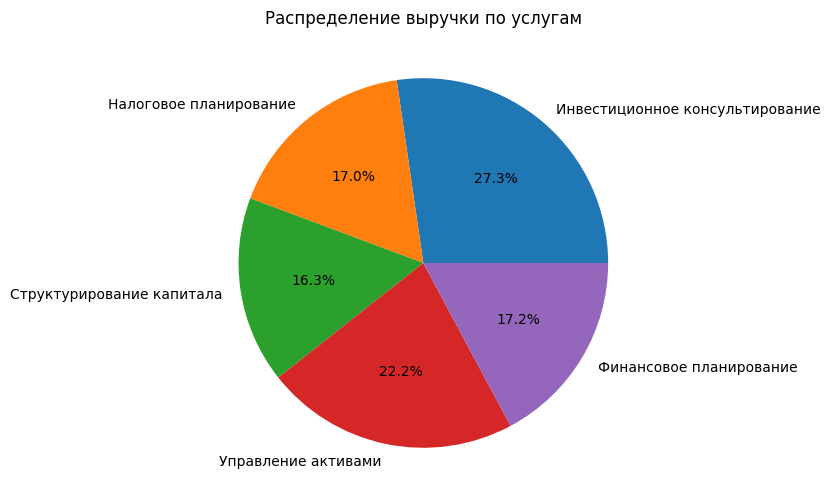

In [52]:
# 4.1 Создать диаграмму выручки по услугам.
service_sum = df_clean_transactions_data.groupby('service')['amount'].sum()
import matplotlib.pyplot as plt

service_sum.plot.pie(autopct='%1.1f%%', figsize=(6, 6))
plt.title('Распределение выручки по услугам')
plt.ylabel('')
plt.show()